# PHY241 Group Project V - Particle Discovery Experiment
### Sandrin Hunkeler, Elisabeth Giryes, Manasi Tiwari

We want to discover a 5 GeV meson decaying to two muons. The plan:
1. **Define a selection** using a BDT to separate signal from background
2. **Determine how long** we need to run the experiment for a 5 sigma discovery

The 10k signal and 10k background samples are Monte Carlo simulations, not real data. We know which is which because we generated them. We use them to train our classifiers and measure how well the selection works. In reality the experiment would only see about 50 signal events per year mixed into 2000 background events. So the plan is: develop a good selection on the large MC samples (Part 1), then apply those efficiencies to the realistic scenario and figure out how long we need to run (Part 2).

### Setup
#### Imports

In [16]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import norm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [17]:
# reset any editor theme and force white backgrounds so the saved PNGs match the report
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
})


#### Load Data

In [18]:
os.makedirs('plots', exist_ok=True)

# load data using pandas, separated by whitespace
sig = pd.read_csv('data/signal_Bs2MuMu.txt', sep=r'\s+')
bkg = pd.read_csv('data/background_combinatorial.txt', sep=r'\s+')

# print number of events and columns in each dataset
print(f"Signal events: {len(sig)}, Background events: {len(bkg)}")
print(f"Columns: {list(sig.columns)}")
sig.head()

Signal events: 10000, Background events: 10000
Columns: ['Mu1_PT', 'Mu2_PT', 'Mu1_P', 'Mu2_P', 'tot_PT', 'VTXCHI2', 'ISO', 'MASS']


,Mu1_PT,Mu2_PT,Mu1_P,Mu2_P,tot_PT,VTXCHI2,ISO,MASS
0,0.504884,10.047968,108.678309,418.772201,9.948355,10.900830,-0.267760,5.431576
1,2.376916,2.867787,3.259937,5.758319,0.597111,7.726661,-0.091041,5.369218
2,2.745118,2.083754,21.563601,5.886996,1.141887,5.365485,0.426770,5.385961
3,2.456457,3.258238,36.856714,40.732084,2.099610,5.385230,-0.097810,5.344424
4,4.603657,3.143709,53.196382,10.199124,7.669011,3.700915,0.354561,5.389953


## Part 1: Define Selection (Section 3)

### 1a - Feature histograms

Let's look at all 8 features and see which ones separate signal from background best.

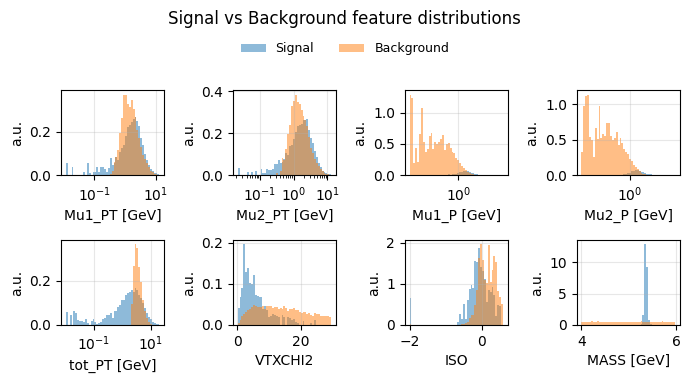

In [19]:
# define features and units for plotting
features = sig.columns.tolist()

units = {
    'Mu1_PT': '[GeV]', 'Mu2_PT': '[GeV]',
    'Mu1_P': '[GeV]', 'Mu2_P': '[GeV]',
    'tot_PT': '[GeV]', 'VTXCHI2': '',
    'ISO': '', 'MASS': '[GeV]',
}

# momentum features are very skewed, so use log x-axis for easier visualization
log_x_features = ['Mu1_PT', 'Mu2_PT', 'Mu1_P', 'Mu2_P', 'tot_PT']
# plot histograms of each feature for signal and background
fig, axes = plt.subplots(2, 4, figsize=(7, 3.5))
# flatten axes for easy indexing
axes = axes.flatten()

# loop over features and plot histograms
for i, feat in enumerate(features):
    ax = axes[i]
    use_log_x = feat in log_x_features

    # determine bin edges based on combined signal and background distributions
    # use log-spaced bins for skewed features, linear bins otherwise
    if use_log_x:
        lo = max(min(sig[feat].min(), bkg[feat].min()), 1e-3)
        hi = max(sig[feat].quantile(0.99), bkg[feat].quantile(0.99))
        bins = np.logspace(np.log10(lo), np.log10(hi), 50)
    else:
        lo = min(sig[feat].min(), bkg[feat].min())
        hi = max(sig[feat].quantile(0.99), bkg[feat].quantile(0.99))
        bins = np.linspace(lo, hi, 50)

    # plot histograms for signal and background
    ax.hist(sig[feat], bins=bins, density=True, histtype='stepfilled',
            alpha=0.5, label='Signal')
    ax.hist(bkg[feat], bins=bins, density=True, histtype='stepfilled',
            alpha=0.5, label='Background')

    # set log scale if needed
    if use_log_x:
        ax.set_xscale('log')

    # set labels (legend is shared across all subplots, added once below)
    unit = units.get(feat, '')
    ax.set_xlabel(f'{feat} {unit}'.strip())
    ax.set_ylabel('a.u.')
    ax.grid(True, alpha=0.3)

# shared legend at the top of the figure, title below it
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Signal vs Background feature distributions', y=1.08)
plt.tight_layout()
plt.savefig('plots/feature_histograms.png', dpi=200, bbox_inches='tight')
plt.show()


From the histograms we can see that `Mu1_PT`, `Mu2_PT`, and `VTXCHI2` show clear separation between signal and background. `MASS` also separates well, but **we can't use MASS in the BDT** because that would sculpt the mass distribution and bias the fit in Part 2.

### 1b - Fisher scores

The Fisher score quantifies how well a single feature separates two classes:

$$F = \frac{(\mu_s - \mu_b)^2}{\sigma_s^2 + \sigma_b^2}$$

Feature  Fisher Score
VTXCHI2      0.803660
   MASS      0.425375
    ISO      0.258816
  Mu2_P      0.068572
  Mu1_P      0.067968
 tot_PT      0.041046
 Mu1_PT      0.031375
 Mu2_PT      0.028887


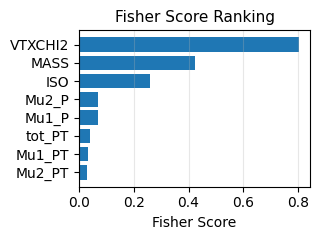


Top 3 features (excluding MASS): ['VTXCHI2', 'ISO', 'Mu2_P']


In [20]:
# compute Fisher score for each feature
fisher_scores = {}

# iterate over features and compute Fisher score using mean and variance of signal and background
for feat in features:
    mu_s, mu_b = sig[feat].mean(), bkg[feat].mean()
    var_s, var_b = sig[feat].var(), bkg[feat].var()
    # fisher score is (mu_s - mu_b)^2 / (var_s + var_b)
    fisher_scores[feat] = (mu_s - mu_b)**2 / (var_s + var_b)

# create a DataFrame to display the scores in a table
fisher_df = pd.DataFrame({
    'Feature': list(fisher_scores.keys()),
    'Fisher Score': list(fisher_scores.values())
})
# sort by Fisher score in descending order
fisher_df = fisher_df.sort_values('Fisher Score', ascending=False)
# reset index for cleaner display
fisher_df = fisher_df.reset_index(drop=True)

# print the table of Fisher scores
print(fisher_df.to_string(index=False))

# plot the Fisher scores as a horizontal bar chart
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.barh(fisher_df['Feature'], fisher_df['Fisher Score'])
ax.set_xlabel('Fisher Score')
ax.set_title('Fisher Score Ranking')
ax.invert_yaxis() # highest score on top
ax.grid(True, alpha=0.3, axis='x') 
plt.tight_layout() # adjust layout to prevent clipping of labels
plt.savefig('plots/fisher_scores.png', dpi=200, bbox_inches='tight')
plt.show()

# top 3 features (excluding MASS)
bdt_features_3 = [f for f in fisher_df['Feature'] if f != 'MASS'][:3]
print(f"\nTop 3 features (excluding MASS): {bdt_features_3}")

### 1c - Rectangular cuts (top 3 features)

For each of the top 3 features we scan thresholds and pick the direction (above/below) that gives the best accuracy. Events must pass all 3 cuts at the same time.

In [21]:
# create labels for signal and background
y_sig = np.ones(len(sig)) # signal labeled as 1
y_bkg = np.zeros(len(bkg)) # background labeled as 0
y_all = np.concatenate([y_sig, y_bkg]) # combined labels for all data

def find_best_cut(signal_values, background_values):
    """Find the best rectangular cut on a single feature to separate signal and background."""
    
    # scan thresholds and try both cut directions
    all_values = np.concatenate([signal_values, background_values])
    thresholds = np.linspace(np.percentile(all_values, 1), np.percentile(all_values, 99), 200)
    
    # loop over thresholds and compute accuracy for both cut directions
    best_accuracy, best_threshold, best_direction = 0, 0, '>'
    # for each threshold, compute true positives and true negatives for both cut directions
    for threshold in thresholds:
        true_positive_count_gt = np.sum(signal_values > threshold)
        true_negative_count_gt = np.sum(background_values <= threshold)
        accuracy_greater_than = (true_positive_count_gt + true_negative_count_gt) / (len(signal_values) + len(background_values))
        
        true_positive_count_lt = np.sum(signal_values < threshold)
        true_negative_count_lt = np.sum(background_values >= threshold)
        accuracy_less_than = (true_positive_count_lt + true_negative_count_lt) / (len(signal_values) + len(background_values))
        
        if accuracy_greater_than > best_accuracy:
            best_accuracy, best_threshold, best_direction = accuracy_greater_than, threshold, '>'
        if accuracy_less_than > best_accuracy:
            best_accuracy, best_threshold, best_direction = accuracy_less_than, threshold, '<'
    # return the best threshold, direction, and accuracy
    return best_threshold, best_direction, best_accuracy

# initialize dictionary to store cuts for each feature
cuts = {}
# find the best cut for each of the top 3 features and store the results
for feature_name in bdt_features_3:
    best_threshold, best_direction, best_accuracy = find_best_cut(sig[feature_name].values, bkg[feature_name].values)
    # store the cut information in the dictionary
    cuts[feature_name] = (best_threshold, best_direction)
    print(f"{feature_name}: cut {best_direction} {best_threshold:.4f}, accuracy = {best_accuracy:.4f}")

# apply all 3 cuts together
sig_pass = np.ones(len(sig), dtype=bool) # start with all signal events passing
bkg_pass = np.ones(len(bkg), dtype=bool) # start with all background events passing

# combine the cuts by applying them sequentially to the signal and background datasets
for feature_name, (threshold, direction) in cuts.items():
    # apply the cut to signal and background, updating the pass arrays
    if direction == '>':
    # for a cut like "feature > threshold", signal events pass if their feature value is greater than the threshold, and background events pass if their feature value is also greater than the threshold
        sig_pass = sig_pass & (sig[feature_name].values > threshold)
        bkg_pass = bkg_pass & (bkg[feature_name].values > threshold)
    # for a cut like "feature < threshold", signal events pass if their feature value is less than the threshold, and background events pass if their feature value is also less than the threshold
    else:
        sig_pass = sig_pass & (sig[feature_name].values < threshold)
        bkg_pass = bkg_pass & (bkg[feature_name].values < threshold)

# compute combined accuracy, signal efficiency, and background rejection for the rectangular cuts
rect_acc = (np.sum(sig_pass) + np.sum(~bkg_pass)) / (len(sig) + len(bkg))
print(f"\nCombined rectangular cut accuracy: {rect_acc:.4f}")
print(f"Signal eff: {np.mean(sig_pass):.4f}, Bkg rejection: {1 - np.mean(bkg_pass):.4f}")

VTXCHI2: cut < 7.8676, accuracy = 0.7498
ISO: cut < -0.0864, accuracy = 0.6720
Mu2_P: cut > 4.7525, accuracy = 0.7654

Combined rectangular cut accuracy: 0.6352
Signal eff: 0.2814, Bkg rejection: 0.9891


### 1d - BDT with 3 features

Now we train a Boosted Decision Tree (BDT), specifically a Gradient Boosting classifier, on the same 3 features. The BDT should do better than rectangular cuts since it can capture non-linear boundaries between signal and background. We split the data 50/50 into train and test sets so we can check for overfitting.

In [22]:
# prepare data for BDT by combining signal and background, and creating labels
X_all = pd.concat([sig, bkg], ignore_index=True)
y_all = np.concatenate([np.ones(len(sig)), np.zeros(len(bkg))])

# 50/50 train/test split to avoid overfitting bias
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.5, random_state=42
)

# train a BDT using the top 3 features
bdt_3 = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42) # number of trees, depth of each tree, learning rate, and random state for reproducibility
# fit the BDT on the training data using only the top 3 features
bdt_3.fit(X_train[bdt_features_3], y_train)

# compute accuracy on training and test sets for the BDT using only the top 3 features
acc_train_3 = accuracy_score(y_train, bdt_3.predict(X_train[bdt_features_3]))
# compute accuracy on the test set for the BDT using only the top 3 features
acc_3 = accuracy_score(y_test, bdt_3.predict(X_test[bdt_features_3]))

print(f"BDT 3-feat train acc: {acc_train_3:.4f}")
print(f"BDT 3-feat test acc:  {acc_3:.4f}")
print(f"Rectangular cuts:     {rect_acc:.4f}")
print(f"Train ~ test, so no overfitting.")

BDT 3-feat train acc: 0.9228
BDT 3-feat test acc:  0.9115
Rectangular cuts:     0.6352
Train ~ test, so no overfitting.


### 1e - BDT with 7 features

Now we use all features except MASS and see how much the accuracy improves. We also look at the feature importances from the BDT.

BDT 7-feat train acc: 0.9766
BDT 7-feat test acc:  0.9644
BDT 3-feat test acc:  0.9115
Again train ~ test, no overfitting.


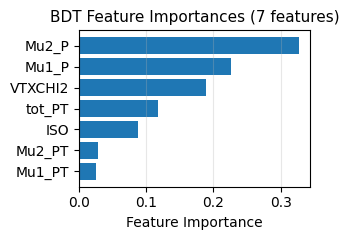

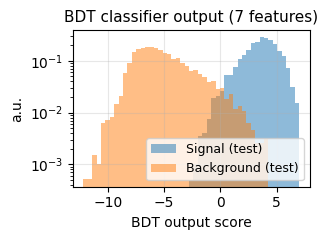

In [23]:
# now train a BDT using all features except MASS, which is the most powerful single feature and would dominate the classifier, preventing it from learning from the other features
bdt_features_7 = [f for f in features if f != 'MASS']

# train the BDT on the training data using the 7 features (excluding MASS)
bdt_7 = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
bdt_7.fit(X_train[bdt_features_7], y_train)

# compute accuracy on training and test sets for the BDT using the 7 features (excluding MASS)
acc_train_7 = accuracy_score(y_train, bdt_7.predict(X_train[bdt_features_7]))
acc_7 = accuracy_score(y_test, bdt_7.predict(X_test[bdt_features_7]))

print(f"BDT 7-feat train acc: {acc_train_7:.4f}")
print(f"BDT 7-feat test acc:  {acc_7:.4f}")
print(f"BDT 3-feat test acc:  {acc_3:.4f}")
print(f"Again train ~ test, no overfitting.")

# feature importances: the BDT provides a feature importance score for each feature, which indicates how much that feature contributes to the classification. 
importances = bdt_7.feature_importances_
sorted_idx = np.argsort(importances) # argsort returns the indices that would sort the array, so we can use these indices to sort the feature names and importance values in ascending order for plotting

# We can plot these importances to see which features the BDT is relying on most for its decisions.
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.barh(np.array(bdt_features_7)[sorted_idx], importances[sorted_idx])
ax.set_xlabel('Feature Importance')
ax.set_title('BDT Feature Importances (7 features)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/bdt_importances.png', dpi=200, bbox_inches='tight')
plt.show()

# BDT score distribution to see how well the BDT separates signal and background
scores_sig = bdt_7.decision_function(X_test[bdt_features_7][y_test == 1])
scores_bkg = bdt_7.decision_function(X_test[bdt_features_7][y_test == 0])

# plot histograms of BDT scores for signal and background
fig, ax = plt.subplots(figsize=(3.3, 2.5))
# determine bin edges based on combined score distributions
lo_s = min(scores_sig.min(), scores_bkg.min()) # lower edge is the minimum score from either signal or background
hi_s = max(scores_sig.max(), scores_bkg.max()) # upper edge is the maximum score from either signal or background
bins_score = np.linspace(lo_s, hi_s, 50) # use the same bin edges for both signal and background to allow direct comparison of the score distributions

# plot histograms for signal and background scores using the same bins
ax.hist(scores_sig, bins=bins_score, density=True, histtype='stepfilled',
        alpha=0.5, label='Signal (test)')
ax.hist(scores_bkg, bins=bins_score, density=True, histtype='stepfilled',
        alpha=0.5, label='Background (test)')
ax.set_xlabel('BDT output score')
ax.set_ylabel('a.u.') # arbitrary units since we are plotting normalized histograms
ax.set_title('BDT classifier output (7 features)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bdt_score_dist.png', dpi=200, bbox_inches='tight')
plt.show()

### 1f - Apply BDT selection

Apply the 7-feature BDT to both samples and measure signal and background efficiencies. Signal efficiency is the fraction of signal we keep, background efficiency is how much background leaks through. We want high signal efficiency and low background leakage.

We evaluate on the test set only, not the full dataset. The BDT was trained on the other half, so using all events would include training data and give us overly optimistic numbers (overfitting bias).

Signal efficiency:     0.9774 +/- 0.0021
Background efficiency: 0.0487 +/- 0.0031
Signal passing:     4920 / 5034
Background passing: 242 / 4966


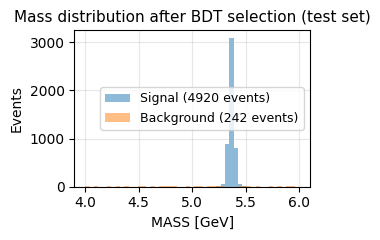

In [24]:
# evaluate on test set only to avoid overfitting bias
signal_test_events = X_test[y_test == 1] # select only the signal events from the test set using the labels (y_test == 1) to create a separate DataFrame for signal events in the test set
background_test_events = X_test[y_test == 0] # same for background events but using (y_test == 0) to select background events

# apply the BDT to the signal and background test sets to get predictions (1 for signal-like, 0 for background-like)
signal_test_predictions = bdt_7.predict(signal_test_events[bdt_features_7])
background_test_predictions = bdt_7.predict(background_test_events[bdt_features_7])

# compute signal efficiency and background efficiency (fraction of events predicted as signal-like) for the test set
signal_efficiency = np.mean(signal_test_predictions == 1)
background_efficiency = np.mean(background_test_predictions == 1)

# binomial uncertainties (our addition, not required, just a useful check)
n_signal_test_events = len(signal_test_events) # number of signal events in the test set, needed to compute the uncertainty on the signal efficiency
n_background_test_events = len(background_test_events) # number of background events in the test set
signal_efficiency_uncertainty = np.sqrt(signal_efficiency * (1 - signal_efficiency) / n_signal_test_events)
background_efficiency_uncertainty = np.sqrt(background_efficiency * (1 - background_efficiency) / n_background_test_events)

# print the efficiencies and the number of events passing the BDT selection for signal and background
print(f"Signal efficiency:     {signal_efficiency:.4f} +/- {signal_efficiency_uncertainty:.4f}") 
print(f"Background efficiency: {background_efficiency:.4f} +/- {background_efficiency_uncertainty:.4f}")
print(f"Signal passing:     {np.sum(signal_test_predictions == 1)} / {n_signal_test_events}") # the number of signal events predicted as signal-like out of the total signal test events
print(f"Background passing: {np.sum(background_test_predictions == 1)} / {n_background_test_events}")

# now we can look at the mass distribution of the events that pass the BDT selection to see if we see a signal peak emerging from the background
signal_mass_after_bdt = signal_test_events.loc[signal_test_predictions == 1, 'MASS'].values
background_mass_after_bdt = background_test_events.loc[background_test_predictions == 1, 'MASS'].values

# plot the mass distribution of the events that pass the BDT selection for signal and background
fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(4.0, 6.0, 50)
ax.hist(signal_mass_after_bdt, bins=bins, histtype='stepfilled',
        alpha=0.5, label=f'Signal ({len(signal_mass_after_bdt)} events)')
ax.hist(background_mass_after_bdt, bins=bins, histtype='stepfilled',
        alpha=0.5, label=f'Background ({len(background_mass_after_bdt)} events)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Events')
ax.set_title('Mass distribution after BDT selection (test set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/mass_after_bdt.png', dpi=200, bbox_inches='tight')
plt.show()

## Part 2: Experiment Duration (Section 4)

### 2a - Composite PDF and toy generation

We fit the background mass shape from the full background sample (all 10k events), then build a composite model to generate toy experiments. The assignment says to establish the exponential on the background.txt sample. We minimize the negative log-likelihood (NLL) to find the best-fit lambda.

- Signal: Gaussian(mu=5, sigma=0.03) GeV
- Background: Exponential in [4.0, 6.0] GeV
- Signal rate after BDT: 50/year times signal efficiency
- Background rate after BDT: 2000/year times background efficiency

Fitted lambda = 0.0283


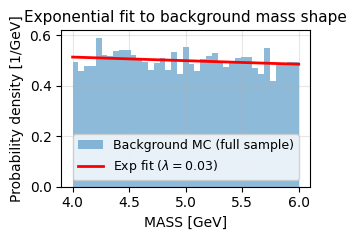


Expected events per year:
  Signal:     48.9
  Background: 97.5


In [25]:
# mass_lower_bound and mass_upper_bound define the range of the mass variable we are interested in, which is around the expected mass of the new particle (5 GeV). 
# We will use this range to fit an exponential function to the background mass distribution
mass_lower_bound, mass_upper_bound = 4.0, 6.0

def exp_nll(background_slope, data, lo=4.0, hi=6.0):
    """Negative log-likelihood for an exponential distribution with parameter lambda, normalized to the range [lo, hi]"""
    # the PDF of an exponential distribution is f(x) = lambda * exp(-lambda * x) for x >= 0, but we need to normalize it to the range [lo, hi] since our data is only in that range.
    normalization_constant = (np.exp(-background_slope * lo) - np.exp(-background_slope * hi)) / background_slope
    # return the negative log-likelihood, which is -sum(log(f(x_i))) for all data points x_i
    return -np.sum(-background_slope * data) + len(data) * np.log(normalization_constant)

# fit lambda from the full background sample (not just post-BDT)
background_mass_values_full = bkg['MASS'].values # get the mass values 
# use scipy's minimize_scalar to find the value of lambda that minimizes the negative log-likelihood for the background mass distribution, with bounds to ensure we get a reasonable fit
fit_result = optimize.minimize_scalar(lambda slope: exp_nll(slope, background_mass_values_full), bounds=(-5, 5), method='bounded')
# the result of the optimization contains the optimal value of lambda in result.x, which we can extract and print
fitted_background_slope = fit_result.x

print(f"Fitted lambda = {fitted_background_slope:.4f}")

# plot the background mass distribution and the fitted exponential function to visualize the fit quality
fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(mass_lower_bound, mass_upper_bound, 40) 
ax.hist(background_mass_values_full, bins=bins, density=True, histtype='stepfilled',
        alpha=0.5, label='Background MC (full sample)')
mass_plot_values = np.linspace(mass_lower_bound, mass_upper_bound, 200)
# compute the normalization constant for the exponential PDF over the range [mass_lower_bound, mass_upper_bound] using the fitted lambda, which is needed to plot the PDF correctly normalized to the data
normalization_constant = (np.exp(-fitted_background_slope * mass_lower_bound) - np.exp(-fitted_background_slope * mass_upper_bound)) / fitted_background_slope 
ax.plot(mass_plot_values, np.exp(-fitted_background_slope * mass_plot_values) / normalization_constant, 'r-', lw=2, label=f'Exp fit ($\\lambda={fitted_background_slope:.2f}$)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Probability density [1/GeV]')
ax.set_title('Exponential fit to background mass shape')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/exp_fit.png', dpi=200, bbox_inches='tight')
plt.show()

# Estimate the expected number of signal and background events we would see in a year of data taking after applying the BDT selection
expected_signal_events_per_year = 50 * signal_efficiency # if the true signal yield is 50 events per year, then the expected number of signal events we would see after applying the BDT selection is 50 times the signal efficiency, since signal_efficiency is the fraction of signal events that pass the BDT selection.
expected_background_events_per_year = 2000 * background_efficiency # similarly, if the true background yield is 2000 events per year
print(f"\nExpected events per year:")
print(f"  Signal:     {expected_signal_events_per_year:.1f}")
print(f"  Background: {expected_background_events_per_year:.1f}")

We generate 1000 toy datasets for 1 year of running. For each toy we Poisson-fluctuate the event counts and sample masses from the PDFs above.

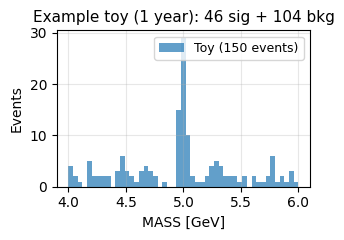

In [26]:
def sample_truncated_exp(background_slope, lo, hi, size):
    """Sample from a truncated exponential distribution with parameter lambda, truncated to the range [lo, hi]."""
    # generate uniform random numbers between 0 and 1
    uniform_random_values = np.random.uniform(0, 1, size)
    # CDF terms of the exponential distribution at the lower and upper bounds
    cdf_term_lower = np.exp(-background_slope * lo)
    cdf_term_upper = np.exp(-background_slope * hi)
    # inverse CDF sampling for a truncated exponential distribution
    return -np.log(cdf_term_lower - uniform_random_values * (cdf_term_lower - cdf_term_upper)) / background_slope

def sample_truncated_gauss(mu, sigma, lo, hi, size):
    """Sample from a truncated Gaussian distribution with parameters mu and sigma, truncated to the range [lo, hi]."""
    # initialize an empty list to store the samples
    accepted_samples = []
    # keep sampling from a normal distribution until we have enough samples that fall within the range [lo, hi]
    while len(accepted_samples) < size:
        # sample more than needed to increase chance of enough in-range values
        candidate_samples = np.random.normal(mu, sigma, size * 2)
        # keep only values in the allowed mass window
        candidate_samples = candidate_samples[(candidate_samples >= lo) & (candidate_samples <= hi)]
        # append valid values
        accepted_samples.extend(candidate_samples)
    # return exactly the requested number of samples
    return np.array(accepted_samples[:size])

def generate_toy(expected_signal_count, expected_background_count, background_slope, mu=5.0, sigma=0.03, lo=4.0, hi=6.0):
    """Generate a toy dataset with signal and background events."""
    # sample the number of signal and background events from Poisson distributions
    sampled_signal_count = np.random.poisson(expected_signal_count)
    sampled_background_count = np.random.poisson(expected_background_count)
    # sample the signal events from a truncated Gaussian distribution
    signal_events = sample_truncated_gauss(mu, sigma, lo, hi, sampled_signal_count)
    # sample the background events from a truncated exponential distribution
    background_events = sample_truncated_exp(background_slope, lo, hi, sampled_background_count)
    # combine and shuffle so signal/background are mixed
    toy_mass_values = np.concatenate([signal_events, background_events])
    np.random.shuffle(toy_mass_values)
    # return masses and the sampled yields
    return toy_mass_values, sampled_signal_count, sampled_background_count

# generate one toy for 1 year as a check
np.random.seed(42)
# generate a toy dataset (using expected yearly yields after BDT selection and fitted background slope)
toy_mass_values, sampled_signal_count, sampled_background_count = generate_toy(
    expected_signal_events_per_year, expected_background_events_per_year, fitted_background_slope
)

# plot the mass distribution of the toy dataset to see if we can visually identify a signal peak emerging from the background, using the same mass range and bins as before
fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(mass_lower_bound, mass_upper_bound, 50)
ax.hist(toy_mass_values, bins=bins, histtype='stepfilled', alpha=0.7,
        label=f'Toy ({len(toy_mass_values)} events)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Events')
ax.set_title(f'Example toy (1 year): {sampled_signal_count} sig + {sampled_background_count} bkg')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/toy_example.png', dpi=200, bbox_inches='tight')
plt.show()

### 2b - Fit toys and signal fraction

For each toy we fit a composite model: $f(m) = f_\text{sig} \cdot f_s(m) + (1 - f_\text{sig}) \cdot f_b(m)$, where $f_\text{sig}$ is the signal fraction. We compare a signal+background fit (free params: $f_\text{sig}$, $\lambda$) against a background-only fit (free param: $\lambda$). Gaussian mean and width are fixed from the known signal properties.

True f_sig: 0.3340
Mean fitted f_sig: 0.3337 +/- 0.0426


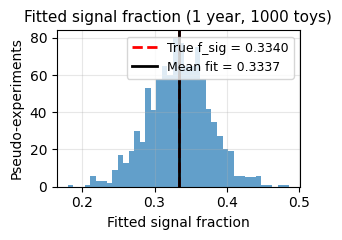

In [27]:
def gauss_pdf(mass_values, mu=5.0, sigma=0.03, lo=4.0, hi=6.0):
    """PDF of a Gaussian distribution with mean mu and standard deviation sigma, normalized to the range [lo, hi]."""
    # normalization constant for the truncated Gaussian distribution
    normalization_constant = norm.cdf(hi, mu, sigma) - norm.cdf(lo, mu, sigma)
    # return value of Gaussian PDF
    return norm.pdf(mass_values, mu, sigma) / normalization_constant

def exp_pdf(mass_values, background_slope, lo=4.0, hi=6.0):
    """PDF of an exponential distribution with parameter lambda, normalized to the range [lo, hi]."""
    # normalization constant for the truncated exponential distribution
    normalization_constant = (np.exp(-background_slope * lo) - np.exp(-background_slope * hi)) / background_slope
    # return value of exponential PDF
    return np.exp(-background_slope * mass_values) / normalization_constant

def composite_nll(parameters, toy_mass_values):
    """Negative log-likelihood for a composite model of signal + background, where the signal is a Gaussian and the background is an exponential."""
    # signal_fraction is between 0 and 1, background_slope is the exponential parameter
    signal_fraction, background_slope = parameters
    # PDF values for each data point under the composite model (weighted sum of both PDFs)
    pdf_values = signal_fraction * gauss_pdf(toy_mass_values) + (1 - signal_fraction) * exp_pdf(toy_mass_values, background_slope)
    # set minimum PDF value to avoid log(0)
    pdf_values[pdf_values < 1e-300] = 1e-300
    # return NLL
    return -np.sum(np.log(pdf_values))

def bkg_only_nll(parameters, toy_mass_values):
    """Negative log-likelihood for the background-only model (exponential)."""
    # only parameter is lambda for the exponential background
    background_slope = parameters[0]
    # exponential PDF
    pdf_values = exp_pdf(toy_mass_values, background_slope)
    # set minimum PDF value to avoid log(0)
    pdf_values[pdf_values < 1e-300] = 1e-300
    # return NLL
    return -np.sum(np.log(pdf_values))

def fit_toy(toy_mass_values):
    """Fit both the signal+background model and the background-only model to the toy data, and return fit results."""
    # fit signal+background model
    signal_background_fit_result = optimize.minimize(
        composite_nll, x0=[0.1, fitted_background_slope], args=(toy_mass_values,),
        bounds=[(0, 1), (-10, 10)], method='L-BFGS-B'
    )
    fitted_signal_fraction, fitted_background_slope_toy = signal_background_fit_result.x
    nll_signal_background = signal_background_fit_result.fun

    # fit background-only model
    background_only_fit_result = optimize.minimize(
        bkg_only_nll, x0=[fitted_background_slope], args=(toy_mass_values,),
        bounds=[(-10, 10)], method='L-BFGS-B'
    )
    nll_background_only = background_only_fit_result.fun

    return fitted_signal_fraction, fitted_background_slope_toy, nll_signal_background, nll_background_only

# run 1000 toys for 1 year
np.random.seed(123) # random seed for reproducibility
n_toys = 1000 # number of pseudo-experiments (toys) to run
fitted_signal_fractions = [] # list to store the fitted signal fraction from each toy
toy_significances = [] # list to store the significance from each toy

# loop over the number of toys
for _ in range(n_toys):
    # generate a toy dataset for 1 year
    toy_mass_values, _, _ = generate_toy(
        expected_signal_events_per_year, expected_background_events_per_year, fitted_background_slope
    )
    # fit the toy dataset
    fitted_signal_fraction, fitted_background_slope_toy, nll_signal_background, nll_background_only = fit_toy(toy_mass_values)
    # store the fitted signal fraction
    fitted_signal_fractions.append(fitted_signal_fraction)
    # compute the test statistic for this toy
    test_statistic_q = 2 * (nll_background_only - nll_signal_background)
    # ensure q is non-negative
    test_statistic_q = max(test_statistic_q, 0)
    # compute and store significance
    toy_significances.append(np.sqrt(test_statistic_q))

# convert lists to numpy arrays for easier analysis and plotting
fitted_signal_fractions = np.array(fitted_signal_fractions)
toy_significances = np.array(toy_significances)
# compute the true signal fraction
true_signal_fraction = expected_signal_events_per_year / (expected_signal_events_per_year + expected_background_events_per_year)

print(f"True f_sig: {true_signal_fraction:.4f}")
print(f"Mean fitted f_sig: {np.mean(fitted_signal_fractions):.4f} +/- {np.std(fitted_signal_fractions):.4f}")

# plot the distribution of fitted signal fractions
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(fitted_signal_fractions, bins=40, alpha=0.7)
ax.axvline(true_signal_fraction, color='r', ls='--', lw=2, label=f'True f_sig = {true_signal_fraction:.4f}')
ax.axvline(np.mean(fitted_signal_fractions), color='k', ls='-', lw=2, label=f'Mean fit = {np.mean(fitted_signal_fractions):.4f}')
ax.set_xlabel('Fitted signal fraction')
ax.set_ylabel('Pseudo-experiments')
ax.set_title('Fitted signal fraction (1 year, 1000 toys)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/fsig_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

The mean fitted signal fraction matches the true value, so the fit is unbiased.

### 2c - Significance distribution

Using Wilks' theorem: $q = 2(\text{NLL}_{\text{bkg}} - \text{NLL}_{s+b})$ follows $\chi^2(1)$ under the null hypothesis. Significance in sigma is $\sqrt{q}$.

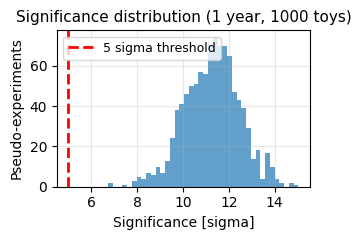

Mean significance: 11.26 sigma
Median significance: 11.33 sigma
Fraction >5 sigma: 1.000


In [28]:
# fraction of toys that exceed 5 sigma significance (typical threshold)
fraction_above_five_sigma = np.mean(toy_significances > 5)

# plot the distribution of significances and indicate the 5 sigma threshold
fig, ax = plt.subplots(figsize=(3.3, 2.5))
histogram_counts, histogram_bin_edges, _ = ax.hist(toy_significances, bins=40, alpha=0.7)
ax.axvline(5.0, color='r', ls='--', lw=2, label='5 sigma threshold')
ax.set_xlabel('Significance [sigma]')
ax.set_ylabel('Pseudo-experiments')
ax.set_title(f'Significance distribution (1 year, {n_toys} toys)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/significance_dist.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mean significance: {np.mean(toy_significances):.2f} sigma")
print(f"Median significance: {np.median(toy_significances):.2f} sigma")
print(f"Fraction >5 sigma: {fraction_above_five_sigma:.3f}")


### 2d - Required experiment duration

We repeat the toy study for different run durations (scaling event counts linearly with time) and find when 95% of toys exceed 5 sigma.

    0.5 months: 0.006
    1.0 months: 0.086
    1.5 months: 0.222
    2.0 months: 0.392
    2.5 months: 0.534
    3.0 months: 0.720
    3.5 months: 0.800
    4.0 months: 0.894
    4.5 months: 0.922
    5.0 months: 0.942
    5.5 months: 0.982
    6.0 months: 0.980
    6.5 months: 0.990
    7.0 months: 0.998
    7.5 months: 1.000
    8.0 months: 1.000
    8.5 months: 1.000
    9.0 months: 1.000
    9.5 months: 1.000
   10.0 months: 1.000
   10.5 months: 1.000
   11.0 months: 1.000
   11.5 months: 1.000
   12.0 months: 1.000
   12.5 months: 1.000

Minimum duration for 95% discovery: 5.1 months


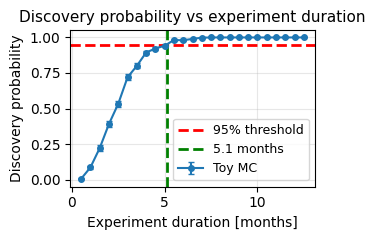

In [29]:
# range of experiment durations to scan (in months)
months_to_scan = np.arange(0.5, 13, 0.5) # 0.5-12 months in 0.5 month steps
# number of toys to run for each duration
n_toys_per_duration = 500
# list to store the discovery fractions for each duration
discovery_probabilities = []

np.random.seed(456) # random seed for reproducibility
# loop over the different experiment durations we want to scan
for run_duration_months in months_to_scan:
    run_duration_years = run_duration_months / 12.0
    # compute expected signal and background events for this duration
    expected_signal_events = expected_signal_events_per_year * run_duration_years
    expected_background_events = expected_background_events_per_year * run_duration_years

    # counter for how many toys exceed 5 sigma significance for this duration
    n_toys_above_five_sigma = 0
    # run the specified number of toys for this duration
    for _ in range(n_toys_per_duration):
        # generate a toy dataset for this duration
        toy_mass_values, _, _ = generate_toy(expected_signal_events, expected_background_events, fitted_background_slope)
        # fit the toy dataset
        _, _, nll_signal_background, nll_background_only = fit_toy(toy_mass_values)
        # compute the test statistic for this toy
        test_statistic_q = max(2 * (nll_background_only - nll_signal_background), 0)
        if np.sqrt(test_statistic_q) > 5:
            n_toys_above_five_sigma += 1

    # fraction of toys that exceed 5 sigma for this duration
    discovery_probability = n_toys_above_five_sigma / n_toys_per_duration
    # store the discovery fraction for this duration
    discovery_probabilities.append(discovery_probability)
    print(f"  {run_duration_months:5.1f} months: {discovery_probability:.3f}")

# convert discovery fractions to a numpy array for easier analysis and plotting
discovery_probabilities = np.array(discovery_probabilities)

# binomial errors on fractions (our addition, not required)
discovery_probability_errors = np.sqrt(discovery_probabilities * (1 - discovery_probabilities) / n_toys_per_duration)

# interpolate to find the 95% crossing
indices_at_or_above_95_percent = np.where(discovery_probabilities >= 0.95)[0] # find first index above threshold
crossing_index = indices_at_or_above_95_percent[0] # index of first duration where we cross 95%

# if crossing is not at the first point, interpolate between neighboring points
if crossing_index > 0 and discovery_probabilities[crossing_index - 1] < 0.95:
    months_below_threshold = months_to_scan[crossing_index - 1]
    months_above_threshold = months_to_scan[crossing_index]
    discovery_prob_below = discovery_probabilities[crossing_index - 1]
    discovery_prob_above = discovery_probabilities[crossing_index]
    minimum_months_for_95_percent = months_below_threshold + (
        (0.95 - discovery_prob_below) / (discovery_prob_above - discovery_prob_below)
        * (months_above_threshold - months_below_threshold)
    )
else:
    minimum_months_for_95_percent = months_to_scan[crossing_index]

print(f"\nMinimum duration for 95% discovery: {minimum_months_for_95_percent:.1f} months")

# plot the discovery probability vs experiment duration with error bars
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.errorbar(months_to_scan, discovery_probabilities, yerr=discovery_probability_errors,
            fmt='o-', markersize=4, capsize=2, label='Toy MC')
ax.axhline(0.95, color='r', ls='--', lw=2, label='95% threshold')
ax.axvline(minimum_months_for_95_percent, color='g', ls='--', lw=2, label=f'{minimum_months_for_95_percent:.1f} months')
ax.set_xlabel('Experiment duration [months]')
ax.set_ylabel('Discovery probability')
ax.set_title('Discovery probability vs experiment duration')
ax.legend()
ax.set_ylim(-0.05, 1.05) # set y-axis limits to show the full range of probabilities
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/discovery_duration.png', dpi=200, bbox_inches='tight')
plt.show()


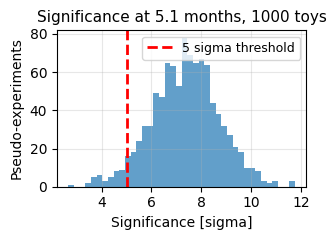

At 5.1 months:
  Mean significance:   7.36 sigma
  Median significance: 7.38 sigma
  Fraction > 5 sigma:  0.958


In [30]:
# additional: significance distribution at the required discovery duration.
# The 1-year distribution above is required by task 4(c), but at 1 year we sit far
# above 5 sigma, so the plot shows 100% discovery and is not very informative.
# Running the same study at the duration scanned in 4(d) gives a distribution that
# actually straddles 5 sigma, which is the regime we care about.
threshold_months = minimum_months_for_95_percent
threshold_years = threshold_months / 12.0
expected_signal_at_threshold = expected_signal_events_per_year * threshold_years
expected_background_at_threshold = expected_background_events_per_year * threshold_years

np.random.seed(789)
threshold_significances = []
for _ in range(n_toys):
    toy_mass_values, _, _ = generate_toy(
        expected_signal_at_threshold, expected_background_at_threshold, fitted_background_slope
    )
    _, _, nll_sb_threshold, nll_b_threshold = fit_toy(toy_mass_values)
    test_statistic_q = max(2 * (nll_b_threshold - nll_sb_threshold), 0)
    threshold_significances.append(np.sqrt(test_statistic_q))
threshold_significances = np.array(threshold_significances)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(threshold_significances, bins=40, alpha=0.7)
ax.axvline(5.0, color='r', ls='--', lw=2, label='5 sigma threshold')
ax.set_xlabel('Significance [sigma]')
ax.set_ylabel('Pseudo-experiments')
ax.set_title(f'Significance at {threshold_months:.1f} months, {n_toys} toys')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/significance_dist_threshold.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"At {threshold_months:.1f} months:")
print(f"  Mean significance:   {np.mean(threshold_significances):.2f} sigma")
print(f"  Median significance: {np.median(threshold_significances):.2f} sigma")
print(f"  Fraction > 5 sigma:  {np.mean(threshold_significances > 5):.3f}")


## Summary

The 7-feature BDT reaches *96.44% test accuracy* and train/test agreement is still good, so overfitting is under control. We evaluate efficiencies on the test set only (as required) and get *signal efficiency = 0.9774 +/- 0.0021* and *background efficiency = 0.0487 +/- 0.0031*.

With these efficiencies, the 1-year toy study gives a mean significance of *11.26 sigma*, and *100.0%* of toys exceed 5 sigma. Scanning run duration, we cross the 95% discovery probability threshold at about *5.1 months*.